In [1]:
#Author: Hiba Ali 
#E-mail: hhibaa802@gmail.com 
#Purpose: QSS Thesis

In [298]:
#import libraries 
import pandas as pd
import os
import re
import numpy as np

In [300]:
#read data
df = pd.read_csv("../data/politicians_list.csv") 
df.head()

,FirstName,LastName,X Handle,St/Dis,Party,Role,Past or current?
0,Alma,Adams,@RepAdams,NC12,D,Representative,Current
1,Robert,Aderholt,@Robert_Aderholt,AL04,R,Representative,Current
2,Pete,Aguilar,@RepPeteAguilar,CA33,D,Representative,Current
3,Mark,Alford,@RepMarkAlford,MO04,R,Representative,Current
4,Rick,Allen,@RepRickAllen,GA12,R,Representative,Current


In [302]:
#check shape
df.shape

#735 users total

(735, 7)

In [304]:
#check for duplicates
duplicates = df.duplicated(subset=['FirstName', 'LastName'], keep=False)

#show rows that are duplicate
df[duplicates]

,FirstName,LastName,X Handle,St/Dis,Party,Role,Past or current?
74,Lou,Correa,@RepLouCorrea,CA46,D,Representative,Current
159,Morgan,Griffith,@RepMGriffith,VA09,R,Representative,Current
438,Jim,Banks,@SenatorBanks,IN,R,Senate,Current
499,Markwayne,Mullin,@SenMullin,OK,R,Senate,Current
521,Elissa,Slotkin,@SenatorSlotkin,MI,D,Senate,Current
644,Elissa,Slotkin,@SenatorSlotkin,NaN,D,Representative,Past
654,Morgan,Griffith,@RepMGriffith,NaN,R,Representative,Past
656,Lou,Correa,@RepLouCorrea,NaN,D,Representative,Past
669,Jim,Banks,@Jim_Banks,NaN,R,Representative,Past
695,Markwayne,Mullin,@MarkwayneMullin,NaN,R,Representative,Past


In [306]:
df = df.dropna(subset=['X Handle'])
df.shape #now have 723 politicians 

(723, 7)

In [308]:
#drop duplicates

# Drop rows with specific indices
rows_to_drop = [644, 654, 656, 669, 695]
df = df.drop(index=rows_to_drop)

# Optional: reset the index
df = df.reset_index(drop=True)

df['X Handle'] = df['X Handle'].str.replace('@', '', regex=False)

print(df.shape)
#now have 718 politicians)

(718, 7)


In [1045]:
df.to_csv("df.csv", index=False)

In [310]:
# Separate the groups
sen_rep = df[df['Role'].isin(['Senator', 'Representative'])]
other = df[~df['Role'].isin(['Senator', 'Representative'])]

# Randomly sample 202 Senators/Representatives out of the 670 total, about 30%
sen_rep_sample = sen_rep.sample(n=202, random_state=42)

# Combine with all other roles
final_df = pd.concat([sen_rep_sample, other], ignore_index=True)

print(final_df.shape)  # Should be 350

(350, 7)


In [312]:
# Remove '@' from 'X Handle' column
final_df['X Handle'] = final_df['X Handle'].str.replace('@', '', regex=False)

In [ ]:
PULLING HEALTH-RELATED TWEETS AND SAVING THEM

In [314]:
import requests
import time
import json

API_BASE_URL = "https://api.data365.co"
API_VERSION = "/v1.1"
API_AUTHORIZATION_TOKEN = "ZXlKMGVYQWlPaUpLVjFRaUxDSmhiR2NpT2lKSVV6STFOaUo5LmV5SnpkV0lpT2lKSWFXSmhRV3hwSWl3aWFXRjBJam94TnpZNU5UQTNOamcyTGpBd05UQXhPSDAuNmpTLTZtbVBGV0F1ZS1McHhXaUIwbUtDUWFDemU4VkRNZVhOSkZ2ckJRTQ=="

In [ ]:
AUTOMATING HEALTH-RELATED POSTS

In [ ]:
API_BASE_URL = "https://api.data365.co"
API_VERSION = "/v1.1"
API_AUTHORIZATION_TOKEN = "ZXlKMGVYQWlPaUpLVjFRaUxDSmhiR2NpT2lKSVV6STFOaUo5LmV5SnpkV0lpT2lKSWFXSmhRV3hwSWl3aWFXRjBJam94TnpZNU5UQTNOamcyTGpBd05UQXhPSDAuNmpTLTZtbVBGV0F1ZS1McHhXaUIwbUtDUWFDemU4VkRNZVhOSkZ2ckJRTQ=="

# Keyword blocks
KEYWORD_BLOCKS = {
    "1A": "health OR medicine OR medical OR medication",
    "1B": "treatment OR symptoms OR diagnosis",
    "2A": "healthcare OR insurance OR medicare OR medicaid",
    "2B": "premiums OR coverage OR patients OR hospitals",
    "3": "flu OR pneumonia OR bronchitis OR strep throat OR sore throat OR cough OR fever OR infection OR contagious",
    "4": "high blood pressure OR hypertension OR heart OR heart disease OR heart rate OR stroke OR cholesterol OR diabetes OR cancer",
    "5": "lupus OR autoimmune OR chronic illness OR inflammation OR immune system",
    "6": "hydration OR diet OR nutrition OR exercise OR workout OR sleep OR wellness"
}


# Function to fetch posts only
def fetch_posts(username, block_name, keywords, max_attempts=10, sleep_time=2):
    update_url = f"{API_BASE_URL}{API_VERSION}/twitter/search/post/update"
    posts_url = f"{API_BASE_URL}{API_VERSION}/twitter/search/post/posts"

    params = {
        "from_profile": username,
        "from_date": "2022-01-01",
        "to_date": "2025-12-31",
        "lang": "en",
        "max_posts": 20,
        "search_type": "latest",
        "max_replies": 3,
        "load_replies": "true",
        "keywords": keywords,
        "access_token": API_AUTHORIZATION_TOKEN
    }

    # Start the search task
    post_response = requests.post(update_url, params=params)
    print(f"Task started for {username} Block {block_name}: {post_response.status_code}")

    attempt = 0
    data = {}
    while attempt < max_attempts:
        posts_response = requests.get(posts_url, params=params)
        if posts_response.status_code == 200:
            data = posts_response.json()
            items = data.get("data", {}).get("items", [])
            if items:
                print(f"{username} Block {block_name}: Retrieved {len(items)} posts")
                break
            else:
                print(f"{username} Block {block_name}, attempt {attempt+1}: No posts yet...")
        else:
            print(f"Failed to fetch posts for {username} (attempt {attempt+1}): {posts_response.status_code}")
        attempt += 1
        time.sleep(sleep_time)

    items = data.get("data", {}).get("items", [])
    if items:
        filename = f"{username} Block {block_name}.json"
        with open(filename, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=4)
        print(f"Saved posts to {filename}")
    else:
        print(f"No posts found for {username} Block {block_name}, skipping save.")

    return items

# Main Execution
start_username = "SecDebHaaland"
start_index = final_df.index[final_df['X Handle'] == start_username][0]

for username in final_df['X Handle'].iloc[start_index:]:
    print(f"\n=== Processing {username} ===")
    for block_name, keywords in KEYWORD_BLOCKS.items():
        fetch_posts(username, block_name, keywords)


=== Processing SecDebHaaland ===
Task started for SecDebHaaland Block 1A: 202
SecDebHaaland Block 1A: Retrieved 20 posts
Saved posts to SecDebHaaland Block 1A.json
Task started for SecDebHaaland Block 1B: 202
SecDebHaaland Block 1B, attempt 1: No posts yet...
SecDebHaaland Block 1B, attempt 2: No posts yet...
SecDebHaaland Block 1B, attempt 3: No posts yet...
SecDebHaaland Block 1B, attempt 4: No posts yet...
SecDebHaaland Block 1B, attempt 5: No posts yet...
SecDebHaaland Block 1B: Retrieved 2 posts
Saved posts to SecDebHaaland Block 1B.json
Task started for SecDebHaaland Block 2A: 202
SecDebHaaland Block 2A, attempt 1: No posts yet...
SecDebHaaland Block 2A, attempt 2: No posts yet...
SecDebHaaland Block 2A, attempt 3: No posts yet...
SecDebHaaland Block 2A, attempt 4: No posts yet...
SecDebHaaland Block 2A, attempt 5: No posts yet...
SecDebHaaland Block 2A: Retrieved 4 posts
Saved posts to SecDebHaaland Block 2A.json
Task started for SecDebHaaland Block 2B: 202
SecDebHaaland Block 

In [ ]:
AUTOMATING HEALTH-RELATED REPLIES

In [ ]:
BLOCKS = ["1A", "1B", "2A", "2B", "3", "4", "5", "6"]


handles_series = final_df["X Handle"].dropna()

if "" in handles_series.values:
    start_index = handles_series[handles_series == ""].index[0]
    usernames_to_process = final_df.loc[start_index:, "X Handle"].dropna().unique()
else:
    print(" not found. Starting from top.")
    usernames_to_process = handles_series.unique()

#Loop through each politician
for username in usernames_to_process:

    print(f"\nProcessing politician: {username}")

    #Loop through blocks
    for block_name in BLOCKS:

        input_filename = f"{username} Block {block_name}.json"
        output_filename = f"{username} Block {block_name} Replies.json"

        #Skip if fie doen't exist
        if not os.path.exists(input_filename):
            print(f"Skipping {input_filename} (file not found)")
            continue

        #Open block file
        with open(input_filename, "r", encoding="utf-8") as f:
            block_data = json.load(f)

        posts = block_data.get("data", {}).get("items", [])

        # Skip if no posts
        if not posts:
            print(f"Skipping {input_filename} (no posts found)")
            continue

        all_replies_output = []

        #Fetch replies for each post
        for post in posts:
            conversation_id = post.get("conversation_id")

            if not conversation_id:
                continue

            print(f"Fetching replies for {username} Block {block_name} - {conversation_id}")

            replies_url = (
                f"{API_BASE_URL}{API_VERSION}/twitter/profile/"
                f"{username}/feed/posts/{conversation_id}/replies"
            )

            params = {
                "order_by": "date_desc",
                "max_page_size": 50,
                "access_token": API_AUTHORIZATION_TOKEN
            }

            response = requests.get(replies_url, params=params)

            if response.status_code == 200:
                replies_json = response.json()
                replies_items = replies_json.get("data", {}).get("items", [])

                all_replies_output.append({
                    "conversation_id": conversation_id,
                    "replies": replies_items
                })
            else:
                print(f"Failed for {conversation_id}: {response.status_code}")

            time.sleep(1)  

        #Save output only if replies exist
        if all_replies_output:

            final_output = {
                "politician": username,
                "block": block_name,
                "posts": all_replies_output
            }

            with open(output_filename, "w", encoding="utf-8") as f:
                json.dump(final_output, f, indent=4)

            print(f"Saved: {output_filename}")
        else:
            print(f"No replies found for {username} Block {block_name}")

print("\nAll politicians processed.")


Processing politician: MayraFlores4TX
Fetching replies for MayraFlores4TX Block 1A - 1508451806187302924
Fetching replies for MayraFlores4TX Block 1A - 1520137165434404865
Fetching replies for MayraFlores4TX Block 1A - 1540478880309460993
Fetching replies for MayraFlores4TX Block 1A - 1557397296484175874
Fetching replies for MayraFlores4TX Block 1A - 1558984034377760776
Fetching replies for MayraFlores4TX Block 1A - 1575972354936950784
Fetching replies for MayraFlores4TX Block 1A - 1576271103781376006
Fetching replies for MayraFlores4TX Block 1A - 1643790685277921283
Fetching replies for MayraFlores4TX Block 1A - 1646993385507500034
Fetching replies for MayraFlores4TX Block 1A - 1661018805269852166
Fetching replies for MayraFlores4TX Block 1A - 1694432554412048692
Fetching replies for MayraFlores4TX Block 1A - 1770471980510101606
Fetching replies for MayraFlores4TX Block 1A - 1792558727272313065
Fetching replies for MayraFlores4TX Block 1A - 1807053284403802280
Fetching replies for Ma

In [ ]:
GET NON-HEALTH TWEETS

In [ ]:
def fetch_top_posts(username, max_attempts=10, sleep_time=2):
    update_url = f"{API_BASE_URL}{API_VERSION}/twitter/search/post/update"
    posts_url = f"{API_BASE_URL}{API_VERSION}/twitter/search/post/posts"
    params = {
        "from_profile": username,
        "from_date": "2022-01-01",
        "to_date": "2025-12-31",
        "lang": "en",
        "max_posts": 20,
        "search_type": "top",   
        "max_replies": 3,
        "load_replies": "true",
        "access_token": API_AUTHORIZATION_TOKEN
    }
    post_response = requests.post(update_url, params=params)
    print(f"Task started for {username}: {post_response.status_code}")
    attempt = 0
    data = {}
    while attempt < max_attempts:
        posts_response = requests.get(posts_url, params=params)
        if posts_response.status_code == 200:
            data = posts_response.json()
            items = data.get("data", {}).get("items", [])
            if items:
                print(f"{username}: Retrieved {len(items)} posts")
                break
            else:
                print(f"{username}, attempt {attempt+1}: No posts yet...")
        else:
            print(f"Failed for {username} (attempt {attempt+1}): {posts_response.status_code}")
        
        attempt += 1
        time.sleep(sleep_time)
    items = data.get("data", {}).get("items", [])
    if items:
        filename = f"{username}.json"
        with open(filename, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=4)
        print(f"Saved posts to {filename}")
    else:
        print(f"No posts found for {username}, skipping save.")
#Execution
for username in new_df["X Handle"].dropna().unique():
    print(f"\n=== Processing {username} ===")
    fetch_top_posts(username)
print("\nAll Non-Health Tweets processed.")

In [ ]:
GET REPLIES FOR NON-HEALTH TWEETS

In [ ]:
for username in new_df["X Handle"].dropna().unique():
    print(f"\nProcessing replies for politician: {username}")
    input_filename = f"{username}.json"
    output_filename = f"{username} Replies.json"
    # Skip if the politician doesn't have a posts file
    if not os.path.exists(input_filename):
        print(f"Skipping {input_filename} (file not found)")
        continue
    with open(input_filename, "r", encoding="utf-8") as f:
        post_data = json.load(f)
    posts = post_data.get("data", {}).get("items", [])
    if not posts:
        print(f"No posts found in {input_filename}, skipping.")
        continue
    all_replies_output = []
    for post in posts:
        conversation_id = post.get("conversation_id")
        if not conversation_id:
            continue
        print(f"Fetching replies for {username} - {conversation_id}")
        replies_url = f"{API_BASE_URL}{API_VERSION}/twitter/profile/{username}/feed/posts/{conversation_id}/replies"
        
        params = {
            "order_by": "date_desc",
            "max_page_size": 50,
            "access_token": API_AUTHORIZATION_TOKEN
        }
        response = requests.get(replies_url, params=params)
        if response.status_code == 200:
            replies_json = response.json()
            replies_items = replies_json.get("data", {}).get("items", [])
            all_replies_output.append({
                "conversation_id": conversation_id,
                "replies": replies_items
            })
        else:
            print(f"Failed for {conversation_id}: {response.status_code}")
        time.sleep(1) 
    # Save Output
    if all_replies_output:
        final_output = {
            "politician": username,
            "posts": all_replies_output
        }
        with open(output_filename, "w", encoding="utf-8") as f:
            json.dump(final_output, f, indent=4)
        print(f"Saved: {output_filename}")
    else:
        print(f"No replies found for {username}")
print("\nAll Non-Health Replies processed.")

In [ ]:
MAKE MASTER DATA SET

In [ ]:
master_data = {}

#Loop through folder JSONs
for filename in os.listdir():
    if not filename.endswith(".json"):
        continue

    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)

    #Health Tweets
    if "Block" in filename and "Replies" not in filename:

        username = filename.split(" Block ")[0]
        block = filename.split("Block ")[1].replace(".json", "")

        posts = data.get("data", {}).get("items", [])

        for post in posts:

            conversation_id = post.get("conversation_id")

            key = (username, conversation_id)

            master_data[key] = {
                "username": username,
                "block": block,
                "tweet_type": "health",
                "tweet_text": post.get("text"),
                "created_time": post.get("created_time"),
                "favorite_count": post.get("favorite_count"),
                "reply_count": post.get("reply_count"),
                "retweet_count": post.get("retweet_count"),
                "quote_count": post.get("quote_count"),
                "view_count": post.get("view_count"),
                "replies": []
            }

    #Health Replies
    elif "Block" in filename and "Replies" in filename:

        username = filename.split(" Block ")[0]
        block = filename.split("Block ")[1].replace(" Replies.json", "")

        posts = data.get("posts", [])

        for post in posts:

            conversation_id = post.get("conversation_id")
            replies = post.get("replies", [])

            key = (username, conversation_id)

            if key in master_data:
                for reply in replies:
                    master_data[key]["replies"].append(reply.get("text"))

    #Non-Health Tweets
    elif "Block" not in filename and "Replies" not in filename:

        username = filename.replace(".json", "")

        posts = data.get("data", {}).get("items", [])

        for post in posts:

            conversation_id = post.get("conversation_id")

            key = (username, conversation_id)

            master_data[key] = {
                "username": username,
                "block": None,
                "tweet_type": "non_health",
                "tweet_text": post.get("text"),
                "created_time": post.get("created_time"),
                "favorite_count": post.get("favorite_count"),
                "reply_count": post.get("reply_count"),
                "retweet_count": post.get("retweet_count"),
                "quote_count": post.get("quote_count"),
                "view_count": post.get("view_count"),
                "replies": []
            }

    #Non-Health Replies
    elif "Replies" in filename and "Block" not in filename:

        username = filename.replace(" Replies.json", "")

        posts = data.get("posts", [])

        for post in posts:

            conversation_id = post.get("conversation_id")
            replies = post.get("replies", [])

            key = (username, conversation_id)

            if key in master_data:
                for reply in replies:
                    master_data[key]["replies"].append(reply.get("text"))

#convert dictionary to dataframe (one row per tweet or reply)

rows = []

for key, value in master_data.items():

    #add the original tweet row
    rows.append({
        "username": value["username"],
        "block": value["block"],
        "tweet_type": value["tweet_type"],
        "conversation_id": key[1],
        "text": value["tweet_text"],
        "row_type": "tweet",
        "created_time": value["created_time"],
        "favorite_count": value["favorite_count"],
        "reply_count": value["reply_count"],
        "retweet_count": value["retweet_count"],
        "quote_count": value["quote_count"],
        "view_count": value["view_count"]
    })

    #add one row per reply
    for reply in value["replies"]:
        if reply and reply.strip() != "":
            rows.append({
                "username": value["username"],
                "block": value["block"],
                "tweet_type": value["tweet_type"],
                "conversation_id": key[1],
                "text": reply,
                "row_type": "reply",
                "created_time": None,
                "favorite_count": None,
                "reply_count": None,
                "retweet_count": None,
                "quote_count": None,
                "view_count": None
            })

final_df = pd.DataFrame(rows)

#save output
final_df.to_csv("ALL_TWEETS_MASTER.csv", index=False)

Master dataset created!


In [316]:
all_tweets = pd.read_csv("ALL_TWEETS_MASTER.csv")
all_tweets.head()

,username,block,tweet_type,conversation_id,text,row_type,created_time,favorite_count,reply_count,retweet_count,quote_count,view_count
0,RepGwenMoore,2B,health,1940143080637964748,What did the American people buy with the $4 t...,tweet,2025-07-01T20:18:51,22.0,12.0,14.0,2.0,1636.0
1,RepGwenMoore,2B,health,1940143080637964748,@RepGwenMoore https://t.co/g3hDlL5JSW,reply,NaN,NaN,NaN,NaN,NaN,NaN
2,RepGwenMoore,2B,health,1940143080637964748,@RepGwenMoore Yawn.,reply,NaN,NaN,NaN,NaN,NaN,NaN
3,RepGwenMoore,2B,health,1940143080637964748,THANK YOU for pointing out that removing the u...,reply,NaN,NaN,NaN,NaN,NaN,NaN
4,RepGwenMoore,2B,health,1940143080637964748,@RepGwenMoore if your a dorky lookin guy you ...,reply,NaN,NaN,NaN,NaN,NaN,NaN


In [318]:
all_tweets["username"].nunique()

#out of the 713 initial politicians, only 658 ended up included. This means that 55 politicians had no tweets that matched the health keywords

658

In [320]:
all_tweets = all_tweets.drop_duplicates(subset=["conversation_id", "text"])

In [322]:
len(all_tweets)

207956

In [16]:
all_tweets.to_csv("ALL_TWEETS_MASTER_FINAL.csv", index=False)

In [61]:
# takes a 2 column csv, adds a third column
#first column is ID, second column is the text 
#label studio then allows you to give it a labeling structure (binary structure)
#once you get ~10-15 positives and negatives and starts running a model and gives the ones that are hard to classify, would have to classify myself
# theres an option to do a test, of the performance of the model 
#should't be a final model, should do separate model on python but still useful to tell you which rows are most useful and how well the class. model is working
#multiclass labeling where also labeling sentiment along with the misinformation. before that, need to know if the replies are replying to the misinformation or not. do classification model first for main tweets, and once that performs well, take that classification, put it in as part of the text 
# 3 dolumns : conversatin id, text, 0 or 1 to label misinformation
#replies i want to look at sentiment
#were they part of a controversy, covid, etc are things i may also end up labeling for
# need at about over 80% accuracy 

In [324]:
#create a tweets only df:

tweets_df = all_tweets[
    (all_tweets["row_type"] == "tweet") & (all_tweets["tweet_type"] == "health")
][["conversation_id", "text"]].copy()

tweets_label = tweets_df.copy()

tweets_label["id"] = range(1, len(tweets_label) + 1)

tweets_label = tweets_label[["id", "conversation_id", "text"]]

tweets_label.to_csv("tweet_labeling.csv", index=False)

In [326]:
#create replies only df:

replies_df = all_tweets[
    (all_tweets["row_type"] == "reply") & (all_tweets["tweet_type"] == "health")
][["conversation_id", "text"]].copy()

replies_label = replies_df.copy()

replies_label["id"] = range(1, len(replies_label) + 1)

replies_label = replies_label[["id", "conversation_id", "text"]]

replies_label.to_csv("reply_labeling.csv", index=False)

In [328]:
master = pd.read_csv("ALL_TWEETS_MASTER_FINAL.csv")
count = master[(master["tweet_type"] == "health") & (master["row_type"] == "tweet")].shape[0]
print(count)

22233


In [370]:
master = pd.read_csv("ALL_TWEETS_MASTER_FINAL.csv")
df_working = master.copy()

#clean column names
df_working.columns = df_working.columns.str.strip()

#standardize other columns used in merging
df_working["conversation_id"] = df_working["conversation_id"].astype(str).str.strip()
df_working["text"] = df_working["text"].astype(str).str.strip()
df_working["row_type"] = df_working["row_type"].astype(str).str.strip().str.lower()

for col in ["username", "created_time", "tweet_type", "block"]:
    if col in df_working.columns:
        df_working[col] = df_working[col].astype(str).str.strip()


#create a text normalization function

def normalize_text(x):
    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)
    return x

df_working["text_norm"] = df_working["text"].apply(normalize_text)


#split the working data into tweets and replies

tweets_master = df_working[df_working["row_type"] == "tweet"].copy()
replies_master = df_working[df_working["row_type"] == "reply"].copy()

print("Tweet rows in master:", len(tweets_master))
print("Reply rows in master:", len(replies_master))


#load and parse tweet label studio

with open("project-4-at-2026-04-18-18-15-d9734dc3.json", "r", encoding="utf-8") as f:
    tweet_tasks = json.load(f)

tweet_rows = []

for task in tweet_tasks:
    data = task.get("data", {})
    annotations = task.get("annotations", [])
    
    if not annotations:
        continue
    
    result = annotations[0].get("result", [])
    
    claim_type = []
    evidence = []
    emotion = []
    valence = []
    
    for r in result:
        fname = r.get("from_name")
        choices = r.get("value", {}).get("choices", [])
        
        if fname == "claim_type":
            claim_type.extend(choices)
        elif fname == "evidence":
            evidence.extend(choices)
        elif fname == "emotion":
            emotion.extend(choices)
        elif fname == "misinformation":
            valence.extend(choices)
    
    tweet_rows.append({
        "conversation_id": str(data.get("conversation_id", "")).strip(),
        "text": str(data.get("text", "")).strip(),
        "claim_type": claim_type,
        "evidence": evidence,
        "emotion": emotion,
        "valence": valence
    })

tweet_labels = pd.DataFrame(tweet_rows)

tweet_labels["conversation_id"] = tweet_labels["conversation_id"].astype(str).str.strip()
tweet_labels["text"] = tweet_labels["text"].astype(str).str.strip()
tweet_labels["text_norm"] = tweet_labels["text"].apply(normalize_text)

print("Parsed tweet labels:", len(tweet_labels))


#create binary columns for tweet label columns

claim_labels = {
    "Medical claim": "medical_claim",
    "Health policy / legislation claim": "health_policy_claim",
    "Opinion / political framing": "opinion_political_framing",
    "Personal anecdote": "personal_anecdote",
    "Other/unclear": "other_unclear_claim",
    "Healthcare access / provider claim": "healthcare_access_provider_claim",
    "Public health / social determinants claim": "public_health_social_determinants_claim",
    "Administrative / program performance claim": "administrative_program_performance_claim",
}

evidence_labels = {
    "Citation to research or data": "citation_research_data",
    "Citation to expert or institution": "citation_expert_institution",
    "Citation to news or media source": "citation_news_media",
    "Anecdotal evidence": "anecdotal_evidence",
    "No citation provided": "no_citation_provided",
    "Survey": "survey_evidence",
}

emotion_labels = {
    "Fear/threat framing": "fear_threat_framing",
    "Anger/blame framing": "anger_blame_framing",
    "Urgency": "urgency_framing",
    "Neutral": "emotion_neutral",
    "Positive hope / reassurance": "positive_hope_reassurance",
    "Compassion / sympathy": "compassion_sympathy",
}

valence_labels = {
    "Supports the claim or policy": "valence_supports",
    "Opposes the claim or policy": "valence_opposes",
    "Neutral": "valence_neutral",
}

for label, col in claim_labels.items():
    tweet_labels[col] = tweet_labels["claim_type"].apply(lambda x: int(label in x))

for label, col in evidence_labels.items():
    tweet_labels[col] = tweet_labels["evidence"].apply(lambda x: int(label in x))

for label, col in emotion_labels.items():
    tweet_labels[col] = tweet_labels["emotion"].apply(lambda x: int(label in x))

for label, col in valence_labels.items():
    tweet_labels[col] = tweet_labels["valence"].apply(lambda x: int(label in x))

tweet_label_cols = (
    list(claim_labels.values()) +
    list(evidence_labels.values()) +
    list(emotion_labels.values()) +
    list(valence_labels.values())
)


#check for duplicate tweet merge

tweet_dupes = tweet_labels.duplicated(subset=["conversation_id", "text_norm"], keep=False)
print("Duplicate tweet label keys:", tweet_dupes.sum())


tweet_labels = tweet_labels.drop_duplicates(subset=["conversation_id", "text_norm"])


#merge tweet labels onto tweet rows

tweets_labeled = tweets_master.merge(
    tweet_labels[["conversation_id", "text_norm"] + tweet_label_cols],
    on=["conversation_id", "text_norm"],
    how="left"
)

print("Tweet rows matched to labels:",
      tweets_labeled[tweet_label_cols].notna().any(axis=1).sum(),
      "out of", len(tweets_labeled))



Tweet rows in master: 30472
Reply rows in master: 177484
Parsed tweet labels: 1028
Duplicate tweet label keys: 0
Tweet rows matched to labels: 1028 out of 30472


In [332]:
#breakdown of the ones i manually labeled 
tweet_cols = [
    "medical_claim",
    "health_policy_claim",
    "opinion_political_framing",
    "personal_anecdote",
    "healthcare_access_provider_claim",
    "public_health_social_determinants_claim",
    "administrative_program_performance_claim",
    "citation_research_data",
    "citation_expert_institution",
    "citation_news_media",
    "anecdotal_evidence",
    "no_citation_provided",
    "survey_evidence",
    "fear_threat_framing",
    "anger_blame_framing",
    "urgency_framing",
    "positive_hope_reassurance",
    "compassion_sympathy",
    "valence_supports",
    "valence_opposes",
    "valence_neutral"
]

tweets = pd.read_csv("tweets_labeled_merged.csv")
for col in tweet_cols:
    print(col, tweets[col].sum(skipna=True))

medical_claim 234.0
health_policy_claim 768.0
opinion_political_framing 652.0
personal_anecdote 56.0
healthcare_access_provider_claim 98.0
public_health_social_determinants_claim 24.0
administrative_program_performance_claim 6.0
citation_research_data 67.0
citation_expert_institution 246.0
citation_news_media 145.0
anecdotal_evidence 55.0
no_citation_provided 567.0
survey_evidence 6.0
fear_threat_framing 264.0
anger_blame_framing 422.0
urgency_framing 305.0
positive_hope_reassurance 121.0
compassion_sympathy 70.0
valence_supports 695.0
valence_opposes 237.0
valence_neutral 93.0


In [336]:
# loop to go through the columns and make predictions 

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

#load and filter data 
tweets = pd.read_csv("tweets_labeled_merged.csv")

#clean text
tweets["tweet_type"] = tweets["tweet_type"].astype(str).str.strip().str.lower()
tweets["text"] = tweets["text"].astype(str).fillna("").str.strip()

#keep the health tweets only 
health_tweets = tweets[tweets["tweet_type"] == "health"].copy()
print(f"Total Health Tweets: {len(health_tweets)}\n")

#a helper function to build and evaluate models to keep the code clean
def run_model(target_col, pipeline, param_grid, cv_folds):
    print(f"MODELING: {target_col.upper()}")
    print("-" * 50)
    
    train_df = health_tweets[health_tweets[target_col].notna()].copy()
    predict_df = health_tweets[health_tweets[target_col].isna()].copy()

    if len(train_df) == 0:
        print(f"Skipping {target_col}: No labeled training data found.")
        return

    y = train_df[target_col].astype(int)
    minority_count = y.value_counts().min()
    
    if minority_count < cv_folds:
        print(f"Skipping {target_col}: Only {minority_count} minority labels, need at least {cv_folds} to run.")
        return

    print(f"Training rows: {len(train_df)} | Prediction rows: {len(predict_df)}")

    X = train_df["text"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    grid_search = GridSearchCV(
        pipeline, param_grid, cv=cv_folds, scoring='f1', n_jobs=-1
    )

    try:
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_

        y_pred = best_model.predict(X_test)
        
        try:
             f1 = round(f1_score(y_test, y_pred), 4)
        except:
             f1 = "N/A"

        print(f"Accuracy: {round(accuracy_score(y_test, y_pred), 4)}")
        print(f"F1 (binary - class 1): {f1}")

        if len(predict_df) > 0:
            predict_df = predict_df.copy()
            predict_df[f"{target_col}_pred"] = best_model.predict(predict_df["text"])
            filename = f"predictions_{target_col}_health_tweets.csv"
            predict_df.to_csv(filename, index=False)
            print(f"Saved: {filename}")
    except Exception as e:
        print(f"Failed to model {target_col}. Reason: {e}")

#Tier 1 (> 400 Labels)
#Best for Subjective Framing: Uses char_wb, lowercase=False


tier_1_cols = [
    "health_policy_claim", "valence_supports", "opinion_political_framing", 
    "no_citation_provided", "anger_blame_framing"
]

pipeline_tier1 = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=False, analyzer='char_wb', min_df=2)),
    ("clf", LinearSVC(class_weight="balanced", random_state=42, dual=False))
])

grid_tier1 = {
    'tfidf__ngram_range': [(3, 4), (4, 5)], 
    'clf__C': [0.01, 0.1, 1.0, 10.0]
}

for col in tier_1_cols:
    run_model(col, pipeline_tier1, grid_tier1, cv_folds=5)


#Tier 2 (100 - 350 Labels)
#Best for Factual Claims: Uses Word N-grams, min_df=1

tier_2_cols = [
    "urgency_framing", "fear_threat_framing", "citation_expert_institution",
    "valence_opposes", "medical_claim", "citation_news_media", "positive_hope_reassurance"
]

pipeline_tier2 = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, analyzer='word', stop_words='english', min_df=1)),
    ("clf", LinearSVC(class_weight="balanced", random_state=42, dual=False))
])

grid_tier2 = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)], 
    'clf__C': [0.01, 0.1, 1.0] #lower C values prevent overfitting on small data
}

for col in tier_2_cols:
    run_model(col, pipeline_tier2, grid_tier2, cv_folds=5)


#Tier 3 (< 100 Labels)
#Uses Word N-Grams, min_df=1, and drops CV to 3 (avoids crashing)

tier_3_cols = [
    "healthcare_access_provider_claim", "valence_neutral", "compassion_sympathy",
    "citation_research_data", "personal_anecdote", "anecdotal_evidence",
    "public_health_social_determinants_claim",
    "survey_evidence"
]

pipeline_tier3 = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, analyzer='word', stop_words='english', min_df=1)),
    ("clf", LinearSVC(class_weight="balanced", random_state=42, dual=False))
])


grid_tier3 = {
    'tfidf__ngram_range': [(1, 1), (1, 2)], 
    'clf__C': [0.001, 0.01, 0.1] 
}


for col in tier_3_cols:
    run_model(col, pipeline_tier3, grid_tier3, cv_folds=3)



Total Health Tweets: 22233

MODELING: HEALTH_POLICY_CLAIM
--------------------------------------------------
Training rows: 1028 | Prediction rows: 21205
Accuracy: 0.8495
F1 (binary - class 1): 0.897
Saved: predictions_health_policy_claim_health_tweets.csv
MODELING: VALENCE_SUPPORTS
--------------------------------------------------
Training rows: 1028 | Prediction rows: 21205
Accuracy: 0.7718
F1 (binary - class 1): 0.8374
Saved: predictions_valence_supports_health_tweets.csv
MODELING: OPINION_POLITICAL_FRAMING
--------------------------------------------------
Training rows: 1028 | Prediction rows: 21205
Accuracy: 0.8447
F1 (binary - class 1): 0.873
Saved: predictions_opinion_political_framing_health_tweets.csv
MODELING: NO_CITATION_PROVIDED
--------------------------------------------------
Training rows: 1028 | Prediction rows: 21205
Accuracy: 0.6845
F1 (binary - class 1): 0.7368
Saved: predictions_no_citation_provided_health_tweets.csv
MODELING: ANGER_BLAME_FRAMING
----------------

In [338]:
#merge the predictions onto the original tweet dataset 


#load
tweets = pd.read_csv("tweets_labeled_merged.csv")

#clean the tweet_type so the filter matches perfectly
tweets["tweet_type"] = tweets["tweet_type"].astype(str).str.strip().str.lower()

all_columns = [
    "health_policy_claim", "valence_supports", "opinion_political_framing", 
    "no_citation_provided", "anger_blame_framing",
    "urgency_framing", "fear_threat_framing", "citation_expert_institution",
    "valence_opposes", "medical_claim", "citation_news_media", "positive_hope_reassurance",
    "healthcare_access_provider_claim", "valence_neutral", "compassion_sympathy",
    "citation_research_data", "personal_anecdote", "anecdotal_evidence",
    "public_health_social_determinants_claim",
    "survey_evidence"
]



#loop through each column and paste the predictions

for col in all_columns:
    filename = f"predictions_{col}_health_tweets.csv"
    
    #check if the model actually created a prediction file for this column
    if os.path.exists(filename):
        #load the newly generated predictions
        pred_df = pd.read_csv(filename)
        
        #create an exact map of where the original blank rows were
        mask = (tweets["tweet_type"] == "health") & tweets[col].isna()
        
        #safety check: ensure the number of blank rows perfectly matches the number of predictions
        if mask.sum() == len(pred_df):
            #paste the 1s and 0s directly into the master dataset
            tweets.loc[mask, col] = pred_df[f"{col}_pred"].values
            print(f"Merged {len(pred_df)} predictions into '{col}'")
        else:
            print(f"Length mismatch for {col}. Skipping merge.")
    else:
        #some Tier 3 columns might have been skipped due to extreme lack of data
        print(f"No prediction file found for '{col}' (likely skipped in Tier 3).")

#save the final dataset
final_filename = "tweets_labeled_merged_ALL_PREDICTIONS.csv"

tweets.to_csv(final_filename, index=False)


Merged 21205 predictions into 'health_policy_claim'
Merged 21205 predictions into 'valence_supports'
Merged 21205 predictions into 'opinion_political_framing'
Merged 21205 predictions into 'no_citation_provided'
Merged 21205 predictions into 'anger_blame_framing'
Merged 21205 predictions into 'urgency_framing'
Merged 21205 predictions into 'fear_threat_framing'
Merged 21205 predictions into 'citation_expert_institution'
Merged 21205 predictions into 'valence_opposes'
Merged 21205 predictions into 'medical_claim'
Merged 21205 predictions into 'citation_news_media'
Merged 21205 predictions into 'positive_hope_reassurance'
Merged 21205 predictions into 'healthcare_access_provider_claim'
Merged 21205 predictions into 'valence_neutral'
Merged 21205 predictions into 'compassion_sympathy'
Merged 21205 predictions into 'citation_research_data'
Merged 21205 predictions into 'personal_anecdote'
Merged 21205 predictions into 'anecdotal_evidence'
Merged 21205 predictions into 'public_health_social

In [340]:
#counts per column for tweets

tweet_predictions = pd.read_csv("tweets_labeled_merged_ALL_PREDICTIONS.csv")
#filter for health tweets only
health_only = tweet_predictions[tweet_predictions["tweet_type"].astype(str).str.strip().str.lower() == "health"]
one_counts = health_only[all_columns].eq(1).sum().sort_values(ascending=False)

print(one_counts)

health_policy_claim                        16682
valence_supports                           15814
opinion_political_framing                  14144
no_citation_provided                       12011
anger_blame_framing                         9628
valence_opposes                             6924
citation_expert_institution                 6819
medical_claim                               5734
urgency_framing                             5636
fear_threat_framing                         4831
citation_news_media                         2869
citation_research_data                      2357
compassion_sympathy                         2259
healthcare_access_provider_claim            1945
anecdotal_evidence                          1856
positive_hope_reassurance                   1790
valence_neutral                             1303
personal_anecdote                            746
public_health_social_determinants_claim      313
survey_evidence                               56
dtype: int64


In [342]:
#import the replies label from LabelStudio and predict the labeling for the remainder of the health-related replies


#parse the label studio json
json_file = "project-6-at-2026-04-18-18-14-e4ee8cd8.json"

with open(json_file, 'r', encoding='utf-8') as f:
    ls_data = json.load(f)

extracted_labels = []
for item in ls_data:
    conv_id = item.get("data", {}).get("conversation_id", "")
    text = item.get("data", {}).get("text", "")
    
    annotations = item.get("annotations", [])
    sentiment = None
    if len(annotations) > 0:
        result = annotations[0].get("result", [])
        if len(result) > 0: 
            choices = result[0].get("value", {}).get("choices", [])
            if len(choices) > 0:
                sentiment = choices[0] 
                
    if sentiment:
        extracted_labels.append({
            "conversation_id": conv_id,
            "text": text,
            "reply_sentiment": sentiment.strip() 
        })
        
labels_df = pd.DataFrame(extracted_labels)
print(f"Extracted {len(labels_df)} manual labels from the JSON.")

labels_df["conversation_id"] = labels_df["conversation_id"].fillna(0).astype(str).str.replace(".0", "", regex=False)
labels_df["text"] = labels_df["text"].astype(str).str.strip()

#Load master csv and filter to health replies
master_df = pd.read_csv("ALL_TWEETS_MASTER_FINAL.csv")

master_df["tweet_type"] = master_df["tweet_type"].astype(str).str.strip().str.lower()
master_df["row_type"] = master_df["row_type"].astype(str).str.strip().str.lower()

health_mask = (master_df["tweet_type"].astype(str).str.strip().str.lower() == "health") & \
              (master_df["row_type"].astype(str).str.strip().str.lower() == "reply")

health_replies_df = master_df[health_mask].copy()
print(f"Total 'health' + 'reply' rows found in Master CSV: {len(health_replies_df)}")

health_replies_df["conversation_id"] = health_replies_df["conversation_id"].fillna(0).astype(str).str.replace(".0", "", regex=False)
health_replies_df["text"] = health_replies_df["text"].astype(str).str.strip()

merged_df = health_replies_df.merge(labels_df, on=["conversation_id", "text"], how="left")

merged_df["reply_positive"] = 0
merged_df["reply_negative"] = 0
merged_df["reply_neutral_unclear"] = 0

merged_df.loc[merged_df["reply_sentiment"] == "Positive", "reply_positive"] = 1
merged_df.loc[merged_df["reply_sentiment"] == "Negative", "reply_negative"] = 1
merged_df.loc[merged_df["reply_sentiment"] == "Neutral/Unclear", "reply_neutral_unclear"] = 1

#Predict the blanks
train_df = merged_df[merged_df["reply_sentiment"].notna()].copy()
predict_df = merged_df[merged_df["reply_sentiment"].isna()].copy()

#clean out any rogue labels from Label Studio
class_counts = train_df["reply_sentiment"].value_counts()
valid_classes = class_counts[class_counts >= 5].index

if len(valid_classes) != len(class_counts):
    rogues = set(class_counts.index) - set(valid_classes)
    print(f"automatically dropping rogue/accidental labels with too few examples: {rogues}")

#filter the training data to only include the main 3 categories
train_df = train_df[train_df["reply_sentiment"].isin(valid_classes)]

print(f"\nModel Training Data: {len(train_df)}")
print(f"Model Prediction Data (The Blanks): {len(predict_df)}\n")

if len(train_df) > 0 and len(predict_df) > 0:
    X = train_df["text"]
    y = train_df["reply_sentiment"].astype(str)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=False, analyzer='char_wb', min_df=2)),
        ("clf", LinearSVC(class_weight="balanced", random_state=42, dual=False))
    ])

    param_grid = {
        'tfidf__ngram_range': [(3, 4), (4, 5)], 
        'clf__C': [0.01, 0.1, 1.0, 10.0]
    }

    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
    #Print the F1 scores
    y_pred = best_model.predict(X_test)
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("F1 (Weighted):", round(f1_score(y_test, y_pred, average="weighted"), 4))
    print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
    new_preds = best_model.predict(predict_df["text"])
    
    merged_df.loc[predict_df.index, "reply_sentiment"] = new_preds

    #re-update the 1/0 for the dataframe in the dataframe so it is perfect
    merged_df["reply_positive"] = (merged_df["reply_sentiment"] == "Positive").astype(int)
    merged_df["reply_negative"] = (merged_df["reply_sentiment"] == "Negative").astype(int)
    merged_df["reply_neutral_unclear"] = (merged_df["reply_sentiment"] == "Neutral/Unclear").astype(int)
    
    print(f"Successfully filled in {len(new_preds)} blank rows")

#Save separate csv
final_filename = "health_replies_FULLY_LABELED.csv"
merged_df.to_csv(final_filename, index=False)


print("\nFinal Value Counts in the CSV:")
print(merged_df["reply_sentiment"].value_counts(dropna=False))

Extracted 499 manual labels from the JSON.
Total 'health' + 'reply' rows found in Master CSV: 144795
automatically dropping rogue/accidental labels with too few examples: {'Oppose'}

Model Training Data: 498
Model Prediction Data (The Blanks): 144296

Accuracy: 0.74
F1 (Weighted): 0.7285

Classification Report:
                  precision    recall  f1-score   support

       Negative     0.8154    0.8983    0.8548        59
Neutral/Unclear     0.3333    0.2500    0.2857        12
       Positive     0.6923    0.6207    0.6545        29

       accuracy                         0.7400       100
      macro avg     0.6137    0.5897    0.5984       100
   weighted avg     0.7218    0.7400    0.7285       100

Successfully filled in 144296 blank rows

Final Value Counts in the CSV:
reply_sentiment
Negative           135819
Positive             6688
Neutral/Unclear      2287
Oppose                  1
Name: count, dtype: int64


In [344]:
#next step, put all the newly labled tweets and replies into one big file again

#load labeled health tweets
tweets_df = pd.read_csv("tweets_labeled_merged_ALL_PREDICTIONS.csv")
tweets_df = tweets_df.drop(columns=["administrative_program_performance_claim"])

#load labeled health replies
replies_df = pd.read_csv("health_replies_FULLY_LABELED.csv")


tweets_df["tweet_type"] = tweets_df["tweet_type"].astype(str).str.strip().str.lower()
replies_df["tweet_type"] = replies_df["tweet_type"].astype(str).str.strip().str.lower()

health_tweets = tweets_df[tweets_df["tweet_type"].astype(str).str.strip().str.lower() == "health"].copy()
health_replies = replies_df[replies_df["tweet_type"].astype(str).str.strip().str.lower() == "health"].copy()

print(f"Verified Health Tweets: {len(health_tweets)}")
print(f"Verified Health Replies: {len(health_replies)}")

#ensure conversation_ids are cleanly formatted so they group perfectly
health_tweets["conversation_id"] = health_tweets["conversation_id"].fillna(0).astype(str).str.replace(".0", "", regex=False)
health_replies["conversation_id"] = health_replies["conversation_id"].fillna(0).astype(str).str.replace(".0", "", regex=False)


#this stacks them on top of each other, seamlessly creating NaNs where columns don't overlap
combined_df = pd.concat([health_tweets, health_replies], ignore_index=True)

#to sort it so the "tweet" appears right before its "replies"
#Tweet = 1, Reply = 2. 
combined_df["row_rank"] = combined_df["row_type"].astype(str).str.strip().str.lower().map({"tweet": 1, "reply": 2}).fillna(3)

combined_df = combined_df.sort_values(by=["conversation_id", "row_rank"]).drop(columns=["row_rank"])

final_filename = "FINAL_HEALTH_DATABASE_TWEETS_AND_REPLIES.csv"
combined_df.to_csv(final_filename, index=False)


Verified Health Tweets: 22233
Verified Health Replies: 144795


In [346]:
#Phase 1 Analysis: Calculating a Misinformation Score
#Based on the checklist: https://www.nfid.org/resource/how-to-spot-health-misinformation/ (also mentioned in Methods section)

final_filename = "FINAL_HEALTH_DATABASE_TWEETS_AND_REPLIES.csv"
df = pd.read_csv(final_filename)

tweet_mask = df["row_type"].astype(str).str.strip().str.lower() == "tweet"

#initialize the new column with blanks
df["misinfo_risk_score"] = np.nan

#start all tweets at a baseline score of 0
scores = pd.Series(0, index=df[tweet_mask].index)

#Apply penalties

# 1. No Citation
scores.loc[df["no_citation_provided"] == 1] += 2

# 2. Anecdotes over Facts
scores.loc[(df["anecdotal_evidence"] == 1) | (df["personal_anecdote"] == 1)] += 2

# 3. Emotional Triggers
scores.loc[
    (df["fear_threat_framing"] == 1) | 
    (df["anger_blame_framing"] == 1) | 
    (df["urgency_framing"] == 1)
] += 2

# 4. Subjective Framing (Opinion instead of fact)
scores.loc[df["opinion_political_framing"] == 1] += 1

#Apply Protection

# 1. Expert/Institution Citation
scores.loc[df["citation_expert_institution"] == 1] -= 2

# 2. Research Data Citation
scores.loc[df["citation_research_data"] == 1] -= 2

#Finalize
# Keep the minimum score at 0. (A score of 0 means perfectly factual/cited or harmless)
# Maximum score achievable here is 7 (High risk of being misinformation)
scores = scores.clip(lower=0)
df.loc[tweet_mask, "misinfo_risk_score"] = scores


df.to_csv(final_filename, index=False)


print("\nDistribution of Misinformation Risk Scores across Health Tweets:")
print(scores.value_counts().sort_index())



Distribution of Misinformation Risk Scores across your Health Tweets:
0    6684
1    1983
2    1779
3    3895
4     748
5    6348
6      53
7     743
Name: count, dtype: int64


In [348]:
#pull an example from each of the misinformation labels 


df = pd.read_csv("FINAL_HEALTH_DATABASE_TWEETS_AND_REPLIES.csv")
tweets_only = df[df["row_type"].astype(str).str.strip().str.lower() == "tweet"].copy()
#the scores can range from 0 to 7
for score in range(8):
    #filter for tweets that exactly match the current score
    subset = tweets_only[tweets_only["misinfo_risk_score"] == score]
    
    print(f"SCORE {score} EXAMPLES (Total Count: {len(subset)})")
    
    if len(subset) == 0:
        print("No tweets received this score.")
        continue
        
    #grab 2 random examples
    sample_size = min(2, len(subset))
    samples = subset.sample(sample_size, random_state=42) #random_state ensures you get the same 2 if you rerun it
    
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        print(f"\n[Example {i}]:")
        
        import textwrap
        print(textwrap.fill(str(row["text"]), width=90))

SCORE 0 EXAMPLES (Total Count: 6684)

[Example 1]:
Thanks to this new major investment from the @EPA, cleanup on this site (which once hosted
one of the largest wood-treatment facilities in the United States) can move forward, with
the ultimate goal of turning the site into a public park for residents and visitors alike
to enjoy.

[Example 2]:
Open Enrollment starts TOMORROW, Saturday, Nov 1!   Need 2026 health coverage? Compare
plans, check savings, and enroll at https://t.co/JkWxs7hSpq: https://t.co/nEVULmQAcg
https://t.co/8dD7LvaFTW
SCORE 1 EXAMPLES (Total Count: 1983)

[Example 1]:
Biden’s restrictions on Association Health Plans are a setback for American workers. I'm
proud to join @RepWalberg in defending affordable healthcare options. Small businesses
deserve the same opportunities as large corporations to provide quality coverage!
https://t.co/Z4Vnnf1zgi

[Example 2]:
As we gather for Christmas, please join me in thanking those who make the holidays
possible. Thank you to our s

In [356]:
# Phase 1B: Sensitivity Analysis (Alternative Scoring)

# start all tweets at a baseline score of 0
alt_scores = pd.Series(0, index=df[tweet_mask].index)

#apply unweighted penalties (+1 for everything)
alt_scores.loc[df["no_citation_provided"] == 1] += 1

alt_scores.loc[(df["anecdotal_evidence"] == 1) | (df["personal_anecdote"] == 1)] += 1

alt_scores.loc[
    (df["fear_threat_framing"] == 1) | 
    (df["anger_blame_framing"] == 1) | 
    (df["urgency_framing"] == 1)
] += 1

alt_scores.loc[df["opinion_political_framing"] == 1] += 1

#apply unweighted Protection (-1 for everything)
alt_scores.loc[df["citation_expert_institution"] == 1] -= 1
alt_scores.loc[df["citation_research_data"] == 1] -= 1

#finalize the alternative Score
alt_scores = alt_scores.clip(lower=0)
df.loc[tweet_mask, "alt_misinfo_risk_score"] = alt_scores

df.to_csv(final_filename, index=False)

print("\nDistribution of the ALTERNATIVE Unweighted Misinformation Scores:")
print(alt_scores.value_counts().sort_index())


Distribution of the ALTERNATIVE Unweighted Misinformation Scores:
0    6684
1    3762
2    4643
3    6401
4     743
Name: count, dtype: int64


In [358]:
#pull an example from each of the alternative misinformation labels 

df = pd.read_csv("FINAL_HEALTH_DATABASE_TWEETS_AND_REPLIES.csv")
tweets_only = df[df["row_type"].astype(str).str.strip().str.lower() == "tweet"].copy()

#the alt scores can range from 0 to 4
for score in range(5):
    #filter for tweets that exactly match the current score
    subset = tweets_only[tweets_only["alt_misinfo_risk_score"] == score]
    
    print(f"ALT SCORE {score} EXAMPLES (Total Count: {len(subset)})")
    
    if len(subset) == 0:
        print("No tweets received this score.")
        continue
        
    #grab 2 random examples
    sample_size = min(2, len(subset))
    samples = subset.sample(sample_size, random_state=42) #random_state ensures you get the same 2 if you rerun it
    
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        print(f"\n[Example {i}]:")
        
        import textwrap
        print(textwrap.fill(str(row["text"]), width=90))
    
    print("-" * 50) #just a separator to make it easy to read

#0 = No net risk factors (or risk was cancelled out by citing an expert/research).
#1 = Contains exactly 1 net risk factor (e.g., just an uncited claim, or just political framing).
#2 = Contains exactly 2 net risk factors (e.g., an angry claim with no citations).
#3 = Contains exactly 3 net risk factors (e.g., an angry, anecdotal claim with no citations).
#4 = Maximum risk. Combines emotion, political framing, anecdotes, and zero citations.

ALT SCORE 0 EXAMPLES (Total Count: 6684)

[Example 1]:
Thanks to this new major investment from the @EPA, cleanup on this site (which once hosted
one of the largest wood-treatment facilities in the United States) can move forward, with
the ultimate goal of turning the site into a public park for residents and visitors alike
to enjoy.

[Example 2]:
Open Enrollment starts TOMORROW, Saturday, Nov 1!   Need 2026 health coverage? Compare
plans, check savings, and enroll at https://t.co/JkWxs7hSpq: https://t.co/nEVULmQAcg
https://t.co/8dD7LvaFTW
--------------------------------------------------
ALT SCORE 1 EXAMPLES (Total Count: 3762)

[Example 1]:
I joined @RepTeresaLF, @RepJudyChu, and the @DemWomenCaucus in calling on the Biden Admin
to finalize a rule improving birth control coverage, including over-the-counter options.
Birth control is health care, and it should be accessible to everyone who wants and needs
it.

[Example 2]:
Millions of Americans are going to see increased health care 

BASELINE SAMPLE SIZE: 22233

1. MISINFORMATION RISK SCORE DISTRIBUTION
Score 0: 30.1% (Count: 6684)
Score 1: 8.9% (Count: 1983)
Score 2: 8.0% (Count: 1779)
Score 3: 17.5% (Count: 3895)
Score 4: 3.4% (Count: 748)
Score 5: 28.6% (Count: 6348)
Score 6: 0.2% (Count: 53)
Score 7: 3.3% (Count: 743)

2. PARTISAN BREAKDOWN
Average Misinformation Risk Score by Party:
  D: 3.02 out of 7
  I: 2.3 out of 7
  R: 1.9 out of 7

Statistical Difference Between D and R: p-value = 0.0000


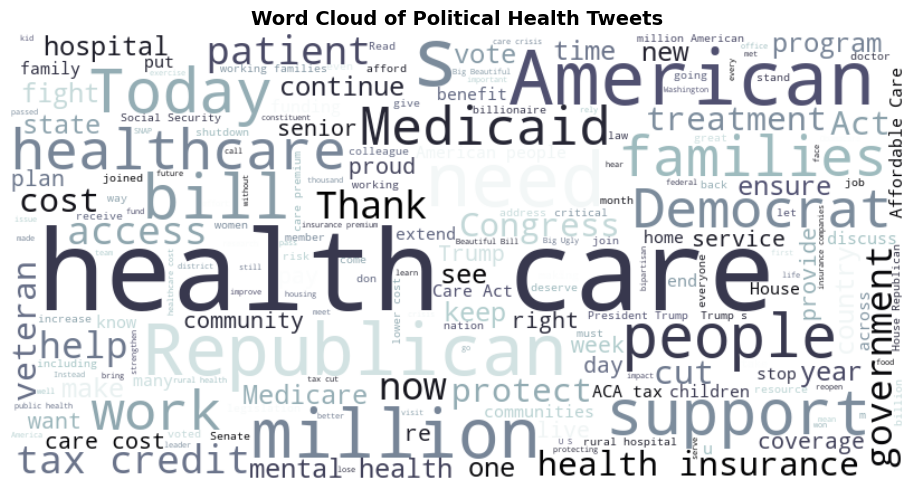

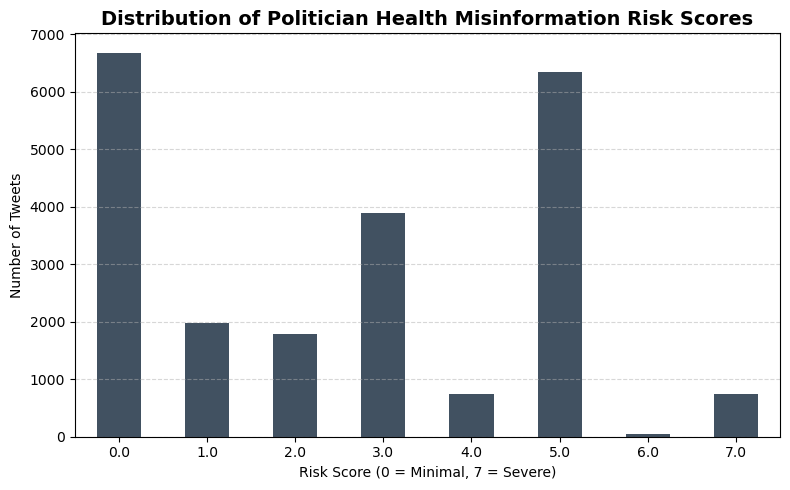

/var/folders/8n/77bk6n_13svf1p2vh3dk7f8m0000gn/T/ipykernel_22144/370864771.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Party", y="misinfo_risk_score", data=plot_data, palette=["#4C72B0", "#C44E52"])


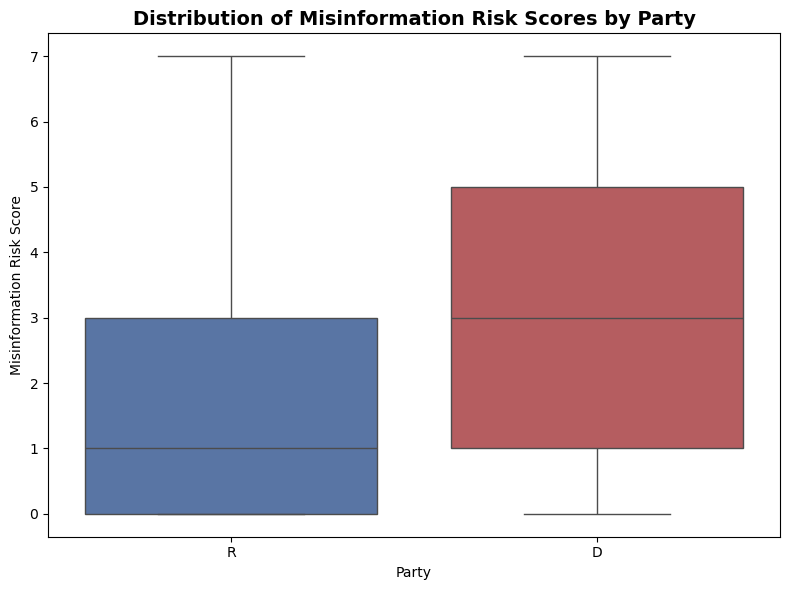

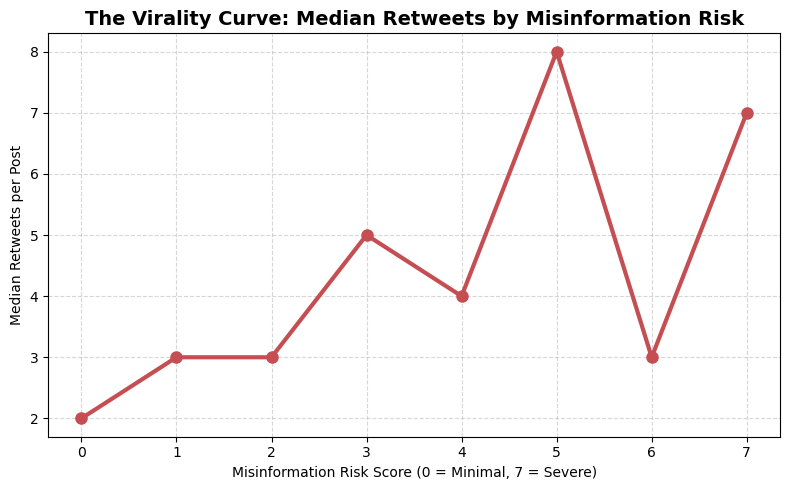

In [360]:
#phase 2: descriptive analysis

!pip install wordcloud
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from wordcloud import WordCloud, STOPWORDS

#color
ACADEMIC_COLOR = '#2c3e50' 

#load data, clean list
df = pd.read_csv("FINAL_HEALTH_DATABASE_TWEETS_AND_REPLIES.csv")
messy_columns = [col for col in df.columns if "Party" in col]
df.drop(columns=messy_columns, inplace=True, errors="ignore")
pols = pd.read_csv("../data/politicians_list.csv")[["X Handle", "Party"]].copy()
pols["X Handle"] = pols["X Handle"].astype(str).str.replace(r"^@", "", regex=True).str.strip().str.lower()
pols.rename(columns={"X Handle": "username"}, inplace=True)
pols = pols.drop_duplicates(subset=["username"])
df["username"] = df["username"].astype(str).str.strip().str.lower()
df = df.merge(pols, on="username", how="left")
df.to_csv("FINAL_HEALTH_DATABASE_TWEETS_AND_REPLIES.csv", index=False)

#filter to health tweets only
health_tweet_mask = (df["row_type"].astype(str).str.strip().str.lower() == "tweet") & \
                    (df["tweet_type"].astype(str).str.strip().str.lower() == "health")

tweets = df[health_tweet_mask].copy()
total_tweets = len(tweets)

print(f"BASELINE SAMPLE SIZE: {total_tweets}")

#printouts of tables
print("\n1. MISINFORMATION RISK SCORE DISTRIBUTION")
risk_counts = tweets["misinfo_risk_score"].value_counts().sort_index()
risk_percents = (tweets["misinfo_risk_score"].value_counts(normalize=True) * 100).sort_index().round(1)
for score, pct in risk_percents.items():
    print(f"Score {int(score)}: {pct}% (Count: {risk_counts[score]})")

print("\n2. PARTISAN BREAKDOWN")
partisan_tweets = tweets.dropna(subset=["Party"])
party_risk = partisan_tweets.groupby("Party")["misinfo_risk_score"].mean().round(2)
print("Average Misinformation Risk Score by Party:")
for party, score in party_risk.items():
    print(f"  {party}: {score} out of 7")

#run a quick statistical t-test for partisan differences
from scipy import stats
dems = partisan_tweets[partisan_tweets["Party"] == "D"]["misinfo_risk_score"]
reps = partisan_tweets[partisan_tweets["Party"] == "R"]["misinfo_risk_score"]
t_stat, p_val = stats.ttest_ind(dems, reps, nan_policy='omit')
print(f"\nStatistical Difference Between D and R: p-value = {p_val:.4f}")

#visualizations

#chart 1: word cloud of health tweets
plt.figure(figsize=(10, 5))
text = " ".join(tweets["text"].astype(str).tolist())
stopwords = set(STOPWORDS)
stopwords.update(["https", "t", "co", "amp", "will"]) #remove twitter junk
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords, colormap='bone').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Political Health Tweets", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("chart_1_wordcloud.png", dpi=300, bbox_inches='tight')
plt.show()

#chart 2: misinfo risk distribution 
plt.figure(figsize=(8, 5))
risk_counts.plot(kind='bar', color=ACADEMIC_COLOR, alpha=0.9)
plt.title("Distribution of Politician Health Misinformation Risk Scores", fontsize=14, fontweight='bold')
plt.xlabel("Risk Score (0 = Minimal, 7 = Severe)")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout() 
plt.savefig("chart_2_misinfo_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

#chart 3: statistically rigorous partisan difference (boxplot)
plt.figure(figsize=(8, 6))
plot_data = partisan_tweets[partisan_tweets["Party"].isin(["D", "R"])].copy()
sns.boxplot(x="Party", y="misinfo_risk_score", data=plot_data, palette=["#4C72B0", "#C44E52"])
plt.title("Distribution of Misinformation Risk Scores by Party", fontsize=14, fontweight='bold')
plt.xlabel("Party")
plt.ylabel("Misinformation Risk Score")
plt.tight_layout()
plt.savefig("chart_3_partisan_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

#chart 4: the virality curve (median retweets by risk score)
plt.figure(figsize=(8, 5))
engagement_curve = tweets.groupby("misinfo_risk_score")["retweet_count"].median()
engagement_curve.plot(kind='line', marker='o', color='#C44E52', linewidth=3, markersize=8)
plt.title("Median Retweets by Misinformation Risk", fontsize=14, fontweight='bold')
plt.xlabel("Misinformation Risk Score (0 = Minimal, 7 = Severe)")
plt.ylabel("Median Retweets per Post")
plt.xticks(range(0, 8))
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("chart_4_virality_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [366]:
#phase 3: engagement regressions (pruned and formatted)

import numpy as np
import statsmodels.formula.api as smf

#transform the engagement data
tweets["log_retweets"] = np.log1p(tweets["retweet_count"].fillna(0))
tweets["log_likes"]    = np.log1p(tweets["favorite_count"].fillna(0))
tweets["log_replies"]  = np.log1p(tweets["reply_count"].fillna(0)) 
tweets["log_views"]    = np.log1p(tweets["view_count"].fillna(0))  

#clean up independent variables for the formulas
for col in ["fear_threat_framing", "anger_blame_framing", "urgency_framing", 
            "misinfo_risk_score", "alt_misinfo_risk_score", "anecdotal_evidence", 
            "no_citation_provided", "citation_research_data", "citation_expert_institution", 
            "valence_opposes", "opinion_political_framing"]:
    tweets[col] = tweets[col].fillna(0).astype(float)

#party data
tweets["Party"] = tweets["Party"].astype(str).str.strip()
reg_data = tweets[tweets["Party"].isin(["D", "R", "I"])].copy()
reg_data["username"] = reg_data["username"].astype(str)

#regression helper function
def test_hypothesis(model_num, question, formula):
    print(f"\n{'='*60}")
    print(f"MODEL {model_num}: {question}")
    print(f"{'='*60}")
    try:
        model = smf.ols(formula, data=reg_data).fit()
        print(model.summary())
    except Exception as e:
        print(f"model crashed: {e}")

#run the core regressions focused entirely on emotion, evidence, and risk

#1. baseline virality
test_hypothesis("1A", "Does High Misinfo Risk Predict Virality? (Primary Score)", 
                "log_retweets ~ misinfo_risk_score + C(Party, Treatment(reference='D'))")
test_hypothesis("1B", "Sensitivity Check: Does it hold with the alternative score?", 
                "log_retweets ~ alt_misinfo_risk_score + C(Party, Treatment(reference='D'))")

#2. unit of comparison (fixed effects) - neutralizes volume skew
test_hypothesis("2A", "Fixed Effects: Does Misinfo Risk predict Virality Within the same politician?", 
                "log_retweets ~ misinfo_risk_score + C(username)")
test_hypothesis("2B", "Sensitivity Check: Fixed Effects with the alternative score", 
                "log_retweets ~ alt_misinfo_risk_score + C(username)")

#3. emotional drivers
test_hypothesis("3", "Which specific emotion drives virality?", 
                "log_retweets ~ fear_threat_framing + anger_blame_framing + urgency_framing + C(Party, Treatment(reference='D'))")

#4. evidence drivers
test_hypothesis("4", "Does citing evidence protect or hurt engagement?", 
                "log_retweets ~ citation_research_data + citation_expert_institution + no_citation_provided + C(Party, Treatment(reference='D'))")

#5. multivariate (fixed collinearity)
test_hypothesis("5", "Multivariate Model (Controlling for Emotion, Valence, and Evidence)", 
                "log_retweets ~ anger_blame_framing + valence_opposes + opinion_political_framing + no_citation_provided + C(Party, Treatment(reference='D'))")



MODEL 1A: Does High Misinfo Risk Predict Virality? (Primary Score)
                            OLS Regression Results                            
Dep. Variable:           log_retweets   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     931.1
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        11:32:11   Log-Likelihood:                -45174.
No. Observations:               22233   AIC:                         9.036e+04
Df Residuals:                   22229   BIC:                         9.039e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

In [368]:
#phase 4: reply sentiment
all_data = pd.read_csv("FINAL_HEALTH_DATABASE_TWEETS_AND_REPLIES.csv")
health_reply_mask = (all_data["row_type"].astype(str).str.strip().str.lower() == "reply") & \
                    (all_data["tweet_type"].astype(str).str.strip().str.lower() == "health")
replies = all_data[health_reply_mask].copy()
replies["conversation_id"] = replies["conversation_id"].astype(str)
#clean the 1 and 0 sentiment numbers
replies["reply_negative"] = pd.to_numeric(replies["reply_negative"], errors='coerce').fillna(0)
replies["reply_positive"] = pd.to_numeric(replies["reply_positive"], errors='coerce').fillna(0)
#calculate what percentage of a tweet's replies are negative vs positive
reply_stats = replies.groupby("conversation_id").agg(
    pct_negative=("reply_negative", "mean"),
    pct_positive=("reply_positive", "mean")
).reset_index()
reg_data["conversation_id"] = reg_data["conversation_id"].astype(str)
reply_reg_data = reg_data.merge(reply_stats, on="conversation_id", how="inner")
print(f"Total Health Tweets with scorable public replies: {len(reply_reg_data)}")
def test_reply_sentiment(model_num, question, formula):
    print(f"\n{'='*60}")
    print(f"REPLY MODEL {model_num}: {question}")
    print(f"{'='*60}")
    try:
        model = smf.ols(formula, data=reply_reg_data).fit()
        print(model.summary())
    except Exception as e:
        print(f"model crashed: {e}")
#1. negative public response
test_reply_sentiment("1A", "Misinformation Risk and Negative Public Response", 
                     "pct_negative ~ misinfo_risk_score + C(Party, Treatment(reference='D'))")
test_reply_sentiment("1B", "SENSITIVITY CHECK: Alternative score and Negative Response", 
                     "pct_negative ~ alt_misinfo_risk_score + C(Party, Treatment(reference='D'))")
#2. positive audience endorsement
test_reply_sentiment("2A", "Misinformation Risk and Positive Audience Endorsement", 
                     "pct_positive ~ misinfo_risk_score + C(Party, Treatment(reference='D'))")
test_reply_sentiment("2B", "SENSITIVITY CHECK: Alternative score and Positive Response", 
                     "pct_positive ~ alt_misinfo_risk_score + C(Party, Treatment(reference='D'))")
#3. hostile rhetoric
test_reply_sentiment("3", "The Relationship Between Hostile Rhetoric and Negative Reply Sentiment", 
                     "pct_negative ~ anger_blame_framing + C(Party, Treatment(reference='D'))")
#4. mitigating effect of citations
test_reply_sentiment("4", "The Mitigating Effect of Expert Citations on Negative Pushback", 
                     "pct_negative ~ citation_expert_institution + citation_research_data + no_citation_provided + C(Party, Treatment(reference='D'))")

Total Health Tweets with scorable public replies: 9617

REPLY MODEL 1A: Misinformation Risk and Negative Public Response
                            OLS Regression Results                            
Dep. Variable:           pct_negative   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     85.26
Date:                Sat, 02 May 2026   Prob (F-statistic):           1.93e-54
Time:                        11:33:02   Log-Likelihood:                 2962.4
No. Observations:                9617   AIC:                            -5917.
Df Residuals:                    9613   BIC:                            -5888.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      

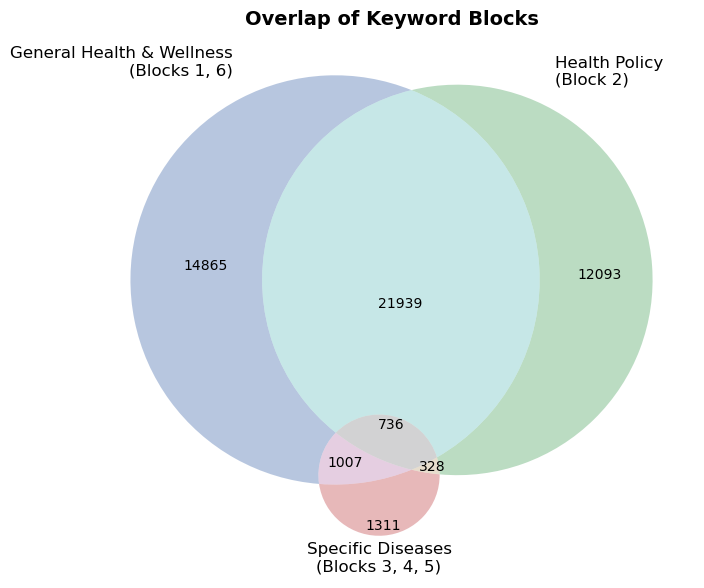

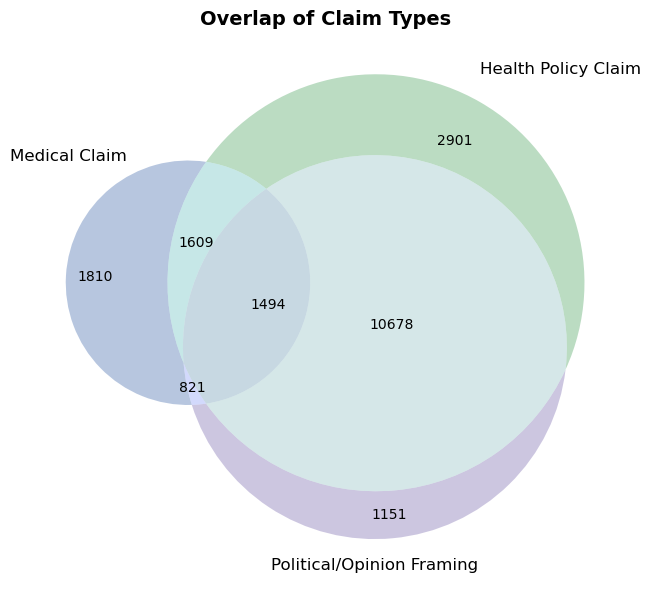

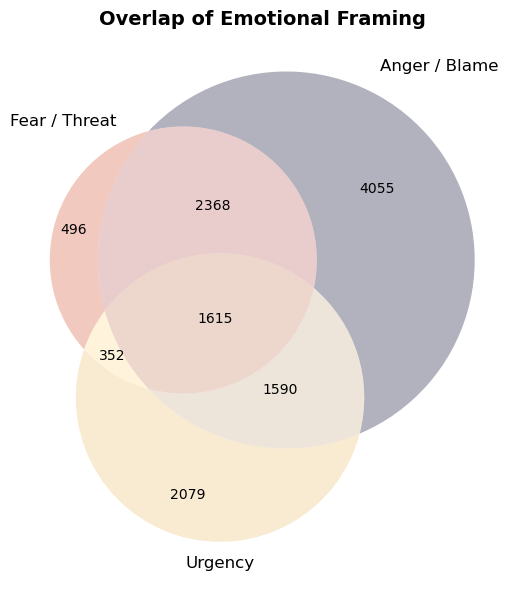

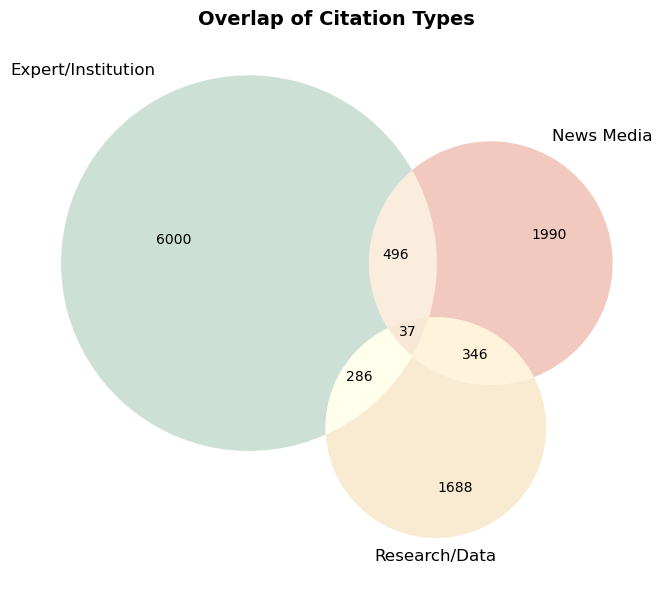

In [354]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# Only look at the health tweets
health_tweets = df[df["tweet_type"] == "health"].copy()
health_tweets["text_lower"] = health_tweets["text"].astype(str).str.lower()

#Diagram 1
set_general = set(health_tweets[health_tweets["text_lower"].str.contains(
    "health|medicine|medical|medication|treatment|symptoms|diagnosis|hydration|diet|nutrition|exercise|workout|sleep|wellness", regex=True)].index)
set_policy = set(health_tweets[health_tweets["text_lower"].str.contains(
    "healthcare|insurance|medicare|medicaid|premiums|coverage|patients|hospitals", regex=True)].index)
set_disease = set(health_tweets[health_tweets["text_lower"].str.contains(
    "flu|pneumonia|bronchitis|strep throat|sore throat|cough|fever|infection|contagious|high blood pressure|hypertension|heart|stroke|cholesterol|diabetes|cancer|lupus|autoimmune|chronic illness|inflammation|immune system", regex=True)].index)

plt.figure(figsize=(8, 6))
venn3([set_general, set_policy, set_disease], 
      set_labels=('General Health & Wellness\n(Blocks 1, 6)', 'Health Policy\n(Block 2)', 'Specific Diseases\n(Blocks 3, 4, 5)'),
      set_colors=('#4C72B0', '#55A868', '#C44E52'))
plt.title("Overlap of Keyword Blocks", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Venn_1_Keyword_Blocks.png", dpi=300, bbox_inches='tight')
plt.show()

#Diagram 2
set_ml_medical = set(health_tweets[health_tweets["medical_claim"] == 1].index)
set_ml_policy = set(health_tweets[health_tweets["health_policy_claim"] == 1].index)
set_ml_political = set(health_tweets[health_tweets["opinion_political_framing"] == 1].index)

plt.figure(figsize=(8, 6))
venn3([set_ml_medical, set_ml_policy, set_ml_political], 
      set_labels=('Medical Claim', 'Health Policy Claim', 'Political/Opinion Framing'),
      set_colors=('#4C72B0', '#55A868', '#8172B3'))
plt.title("Overlap of Claim Types", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Venn_2_Claim_Types.png", dpi=300, bbox_inches='tight')
plt.show()

#Diagram 3
set_fear = set(health_tweets[health_tweets["fear_threat_framing"] == 1].index)
set_anger = set(health_tweets[health_tweets["anger_blame_framing"] == 1].index)
set_urgency = set(health_tweets[health_tweets["urgency_framing"] == 1].index)

plt.figure(figsize=(8, 6))
venn3([set_fear, set_anger, set_urgency], 
      set_labels=('Fear / Threat', 'Anger / Blame', 'Urgency'),
      set_colors=('#E07A5F', '#3D405B', '#F2CC8F'))
plt.title("Overlap of Emotional Framing", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Venn_3_Emotional_Framing.png", dpi=300, bbox_inches='tight')
plt.show()

#Diagram 4
set_expert = set(health_tweets[health_tweets["citation_expert_institution"] == 1].index)
set_media = set(health_tweets[health_tweets["citation_news_media"] == 1].index)
set_research = set(health_tweets[health_tweets["citation_research_data"] == 1].index)

plt.figure(figsize=(8, 6))
venn3([set_expert, set_media, set_research], 
      set_labels=('Expert/Institution', 'News Media', 'Research/Data'),
      set_colors=('#81B29A', '#E07A5F', '#F2CC8F'))
plt.title("Overlap of Citation Types", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Venn_4_Citation_Types.png", dpi=300, bbox_inches='tight')
plt.show()